In [ ]:
# !pip3 install scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import pandas as pd
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim import Adam
import os
from os import listdir
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# from tslearn.datasets import UCR_UEA_datasets
# from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax

## Upload and Part 1 of Processing

In [ ]:
path = "/content/gdrive/MyDrive/Next_Step/participant_data"
contents = os.listdir(path)

In [ ]:
df_list = []
df_list_mag = []

for name in contents:
    current_file = os.path.join(path, name)
    f = pd.read_csv(current_file, low_memory=False)
    f = f.interpolate(method='linear', limit_direction='forward', axis=0)

    # print(f.isnull().values.any())

    # f_mag = pd.DataFrame()
    # # Assuming 'f_trial_1' is your DataFrame
    # f_mag[[' Acc_X', ' Acc_Y', ' Acc_Z']] = f[[' Acc_X', ' Acc_Y', ' Acc_Z']]
    # # .apply(pd.to_numeric)
    # # # Calculate magnitude and create a new column 'magnitude'
    # # f_mag['magnitude'] = (f_mag[' Acc_X']**2 + f_mag[' Acc_Y']**2 + f_mag[' Acc_Z']**2)**0.5
    # f_mag["trial_num"] = f["trial_num"]
    # f_mag["sensor_place"] = f["sensor_place"]


    f_reduced = f.copy()
    # f_reduced = f_reduced[[' Acc_X', ' Acc_Y', ' Acc_Z', ' Gyr_X', ' Gyr_Y', ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', "trial_num", "sensor_place"]]


    df_list.append(f_reduced)
    # df_list_mag.append(f_mag)

In [ ]:
df_list[0].columns

Index(['Unnamed: 0', 'og_df_order', 'PacketCounter', ' SampleTimeFine',
       ' Acc_X', ' Acc_Y', ' Acc_Z', ' FreeAcc_X', ' FreeAcc_Y', ' FreeAcc_Z',
       ' Gyr_X', ' Gyr_Y', ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', ' VelInc_X',
       ' VelInc_Y', ' VelInc_Z', ' OriInc_q0', ' OriInc_q1', ' OriInc_q2',
       ' OriInc_q3', ' Roll', ' Pitch', ' Yaw', ' Latitude', ' Longitude',
       ' Altitude', ' Vel_X', ' Vel_Y', ' Vel_Z', 'trial_num', 'sensor_place',
       'participant_num'],
      dtype='object')

In [ ]:
df_list[1]

,Unnamed: 0,og_df_order,PacketCounter,SampleTimeFine,Acc_X,Acc_Y,Acc_Z,FreeAcc_X,FreeAcc_Y,FreeAcc_Z,...,Yaw,Latitude,Longitude,Altitude,Vel_X,Vel_Y,Vel_Z,trial_num,sensor_place,participant_num
0,0,0,15898,,9.985159,0.142601,-0.447762,-0.0,0.0,0.183522,...,124.310605,,,0.0,,,,6-,B6,2
1,1,1,15899,,10.182849,-0.291799,-0.64202,-0.635468,-0.574394,0.358546,...,165.776382,,,0.0,,,,6-,B6,2
2,2,2,15900,,10.287958,-0.806501,-0.829461,-1.108046,-0.847988,0.445657,...,163.852756,,,0.0,,,,6-,B6,2
3,3,3,15901,,10.015241,-1.648299,-1.641379,-1.740001,-1.760307,0.166777,...,157.31408,,,0.0,,,,6-,B6,2
4,4,4,15902,,10.01443,-1.062207,-1.396401,-1.223053,-1.375819,0.186224,...,154.854796,,,0.0,,,,6-,B6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531055,1976,1976,40783,,13.459191,-1.852354,-0.723288,-4.649697,4.96565,1.968975,...,116.387403,,,0.0,,,,35,B6,2
531056,1977,1977,40784,,15.862051,-2.90855,-0.974049,-6.234798,5.97772,3.839428,...,115.660015,,,0.0,,,,35,B6,2
531057,1978,1978,40785,,18.411807,-3.362078,0.534346,-7.816319,8.779511,4.76041,...,114.911538,,,0.0,,,,35,B6,2
531058,1979,1979,40786,,21.28754,-0.429939,5.054015,-7.29176,15.360322,3.960959,...,114.166151,,,0.0,,,,35,B6,2


In [ ]:
# need to clean trial number column because single digit values have a "-" attached to them
# iterating through each of the 30 participants
for ppant in range(len(df_list)):
    current_df = df_list[ppant]
    current_df['trial_num'] = current_df['trial_num'].astype(str)
    current_df['trial_num'] = current_df['trial_num'].map(lambda x: x.strip('-'))
    current_df['trial_num'] = current_df['trial_num'].astype(int)

In [ ]:
samples_for_all_ppants = []

# iterating through each of the 30 participants
for ppant in range(len(df_list)):
    current_ppant = df_list[ppant]
    sampled_trial_df = pd.DataFrame()
    # iterating through the trials that each participant completed (57)
    for trial in range(1,58,1):
        # for each trial number grab a consecutive list of 400 datapoints
        subset_by_trial = current_ppant.loc[current_ppant["trial_num"] == trial]
        subset_by_trial_and_sensor = subset_by_trial.loc[subset_by_trial["sensor_place"] == "CC"]
        datapoints = len(subset_by_trial_and_sensor)
        n = random.randint(0, datapoints-200)
        lower_limit = n
        upper_limit = n + 199
        sampled_trial = subset_by_trial.loc[(subset_by_trial["og_df_order"] >= lower_limit) & (subset_by_trial["og_df_order"] <= upper_limit)]
        sampled_trial_df= pd.concat([sampled_trial, sampled_trial_df])
    samples_for_all_ppants.append(sampled_trial_df)



In [ ]:
len(df_list)

30

In [ ]:
# for i in range(len(df_list)):
#   print(f"dataset {i}")
#   # print(samples_for_all_ppants[i]['trial_num'].unique())
#   print(len(samples_for_all_ppants[i]['trial_num']))

In [ ]:
samples_for_all_ppants[0].loc[samples_for_all_ppants[0]["trial_num"] == 1]

,Unnamed: 0,og_df_order,PacketCounter,SampleTimeFine,Acc_X,Acc_Y,Acc_Z,FreeAcc_X,FreeAcc_Y,FreeAcc_Z,...,Yaw,Latitude,Longitude,Altitude,Vel_X,Vel_Y,Vel_Z,trial_num,sensor_place,participant_num
139413,473,473,24914,,-9.004462,2.68629,2.298578,0.207538,-0.277278,-0.14522,...,127.851297,,,0.0,,,,1,95,1
139414,474,474,24915,,-8.951851,2.777699,2.344154,0.105129,-0.178816,-0.153329,...,127.920372,,,0.0,,,,1,95,1
139415,475,475,24916,,-8.931765,2.775009,2.404,0.100812,-0.089548,-0.156702,...,128.001483,,,0.0,,,,1,95,1
139416,476,476,24917,,-8.902017,2.8102,2.402053,0.046005,-0.051211,-0.173799,...,128.042105,,,0.0,,,,1,95,1
139417,477,477,24918,,-8.887295,2.846006,2.369523,-0.013506,-0.045355,-0.184806,...,128.097789,,,0.0,,,,1,95,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391529,668,668,25109,,9.693374,-1.340087,-1.098339,0.313317,0.021761,0.029315,...,28.305743,,,0.0,,,,1,9B,1
391530,669,669,25110,,9.772348,-1.005449,-1.223051,0.631509,-0.119622,0.0662,...,28.947672,,,0.0,,,,1,9B,1
391531,670,670,25111,,9.727105,-1.069693,-1.294651,0.544225,-0.168314,0.041875,...,29.543902,,,0.0,,,,1,9B,1
391532,671,671,25112,,9.638217,-1.36063,-1.244818,0.240098,-0.071639,-0.00283,...,30.108589,,,0.0,,,,1,9B,1


In [ ]:
for df in range(len(samples_for_all_ppants)):
    temp_placeholder = samples_for_all_ppants[df]['sensor_place']
    cols = samples_for_all_ppants[df].columns
    samples_for_all_ppants[df][cols] = samples_for_all_ppants[df][cols].apply(pd.to_numeric, errors='coerce')
    samples_for_all_ppants[df]['sensor_place'] = temp_placeholder

In [ ]:
calibration = [1, 2, 3]
FE = [4, 5, 6, 7, 8, 9]
CS = [10, 11, 12, 13, 14, 15]
STU = [16, 18, 20, 22, 24, 26]
STD = [17, 19, 21, 23, 25, 27]
SLPU = [28, 30, 32, 34, 36, 38]
SLPD = [29, 31, 33, 35, 37, 39]
BNKL = [40, 42, 44, 46, 48, 50]
BNKR = [41, 43, 45, 47, 49, 51]
GR = [52, 53, 54, 55, 56, 57]

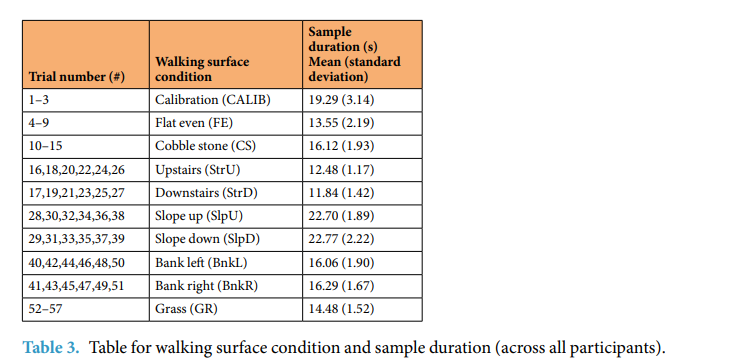

In [ ]:
# iterating through each of the 30 participants
for df in range(len(samples_for_all_ppants)):
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(FE), 'trial_label'] = "FE"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(CS), 'trial_label'] = "CS"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(STU), 'trial_label'] = "STU"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(STD), 'trial_label'] = "STD"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(SLPU), 'trial_label'] = "SLPU"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(SLPD), 'trial_label'] = "SLPD"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(BNKL), 'trial_label'] = "BNKL"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(BNKR), 'trial_label'] = "BNKR"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(GR), 'trial_label'] = "GR"
    samples_for_all_ppants[df].loc[samples_for_all_ppants[df]['trial_num'].isin(calibration), 'trial_label'] = "calibration"



In [ ]:
all_samples = pd.concat(samples_for_all_ppants)

In [ ]:
all_samples["trial_label"].value_counts()

trial_label
GR             216000
BNKR           216000
BNKL           216000
SLPD           216000
SLPU           216000
STD            216000
STU            216000
CS             216000
FE             216000
calibration    108000
Name: count, dtype: int64

In [ ]:
all_samples.shape

(2052000, 36)

In [ ]:
all_samples.to_csv('/content/gdrive/MyDrive/Next_Step/Current Worksheet versions/Varying Input sizes/200_step_samples_forAll.csv', index=False)